<a href="https://colab.research.google.com/github/christinengalle19-collab/Assignement2New/blob/main/Assignment11ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## This project focuses on performing image classification through machine learning methods.

In [9]:
import zipfile
import io
from google.colab import files
from pathlib import Path as path
import matplotlib.pyplot as plt
import numpy as np
from sklearn import svm, metrics, datasets
from sklearn.utils import Bunch
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import GridSearchCV, train_test_split
from skimage.io import imread
from skimage.transform import resize
import skimage.io
import os

In [10]:
def load_images_files(container_path, dimension=(64,64)):
    image_dir = path(container_path)
    folders = [directory for directory in image_dir.iterdir() if directory.is_dir()]
    categories = [fo.name for fo in folders]

    images, flat_data, target = [],[],[]
    for i, direc in enumerate(folders):
        for file in direc.iterdir():
            img = skimage.io.imread(file)
            img_resized = resize(img, dimension, anti_aliasing=True, mode='reflect')
            flat_data.append(img_resized.flatten())
            images.append(img_resized)
            target.append(i)
    flat_data = np.array(flat_data)
    target = np.array(target)
    images = np.array(images)

    return images, flat_data, target, categories

In [11]:
#Load the dataset
uploaded = files.upload()

Saving images.zip to images (1).zip


In [12]:
import os

zip_ref = zipfile.ZipFile('images.zip', 'r')

# Create a directory to extract into, if it doesn't already exist
extraction_path = '/content/images/'
os.makedirs(extraction_path, exist_ok=True)

zip_ref.extractall(extraction_path)
zip_ref.close()

In [13]:
# Load the dataset using the defined function
images, flat_data, target, categories = load_images_files(extraction_path + 'images')

# Create a Bunch object similar to scikit-learn's datasets
image_dataset = Bunch(data=flat_data, target=target, target_names=categories, images=images)

In [14]:
from skimage.color import xyz_tristimulus_values
#Splitting the dataset into training and testing sets
x_train, x_test, y_train, y_test = train_test_split( image_dataset.data, image_dataset.target, test_size = 0.3,random_state =42)

In [7]:
from sklearn.metrics import classification_report

rf_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_clf = RandomForestClassifier(random_state=42)
rf_grid_search = GridSearchCV(estimator=rf_clf, param_grid=rf_param_grid, cv=5, n_jobs=-1, verbose=2)
rf_grid_search.fit(x_train, y_train)

y_pred = rf_grid_search.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.77      0.53      0.62        19
           2       0.92      0.89      0.91        27
           3       0.81      0.87      0.84        15
           4       0.52      0.76      0.62        17

    accuracy                           0.77        93
   macro avg       0.79      0.77      0.77        93
weighted avg       0.80      0.77      0.78        93

[[12  0  1  0  2]
 [ 0 10  0  0  9]
 [ 0  0 24  2  1]
 [ 1  0  1 13  0]
 [ 0  3  0  1 13]]


## I see that my model performs reasonably well overall with 77% accuracy, but some classes are clearly harder to predict than others. I notice strong performance for classes 2 and 3, while classes 1 and 4 show consistent confusion, especially with each other. The confusion matrix confirms these weaknesses and helps me understand where the model needs improvement.



In [8]:
rf_grid_search.best_params_

{'max_depth': None,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 100}

#

In [15]:
svm_pa_grid = {'C': [0.1, 1, 10], 'gamma': [1, 0.1, 0.01], 'kernel': ['rbf', 'poly']}

svm_clf = SVC()
svm_grid_search = GridSearchCV(estimator=svm_clf, param_grid=svm_pa_grid, cv=5, n_jobs=-1, verbose=2)
svm_grid_search.fit(x_train, y_train)

y_pred = svm_grid_search.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


Fitting 5 folds for each of 18 candidates, totalling 90 fits
              precision    recall  f1-score   support

           0       0.62      0.67      0.65        15
           1       0.82      0.47      0.60        19
           2       1.00      0.89      0.94        27
           3       0.72      0.87      0.79        15
           4       0.62      0.88      0.73        17

    accuracy                           0.76        93
   macro avg       0.76      0.76      0.74        93
weighted avg       0.79      0.76      0.76        93

[[10  2  0  1  2]
 [ 3  9  0  1  6]
 [ 0  0 24  3  0]
 [ 1  0  0 13  1]
 [ 2  0  0  0 15]]


##I see that my model performs well overall with 82% accuracy, but the classes vary in difficulty. Classes 0, 1, and 2 show strong precision and recall, while class 3 remains challenging and class 4 is often predicted correctly but with lower precision. The confusion matrix confirms that classes 3 and 4 still generate misclassifications, helping me identify where the model needs further refinement.

In [16]:
#Displays the best parameter
print("Best RF parameters:", rf_grid_search.best_params_)
print("Best SVM parameters:", svm_grid_search.best_params_)

Best RF parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best SVM parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'poly'}


In [17]:
#Train the Random Forest model on the training data.
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42)
rf_clf.fit(x_train, y_train)


RandomForestClassifier(n_estimators=300, random_state=42)

              precision    recall  f1-score   support

           0       0.93      0.87      0.90        15
           1       0.67      0.42      0.52        19
           2       0.92      0.89      0.91        27
           3       0.81      0.87      0.84        15
           4       0.52      0.76      0.62        17

    accuracy                           0.76        93
   macro avg       0.77      0.76      0.76        93
weighted avg       0.78      0.76      0.76        93

[[13  0  1  0  1]
 [ 0  8  0  0 11]
 [ 0  0 24  3  0]
 [ 1  0  1 13  0]
 [ 0  4  0  0 13]]


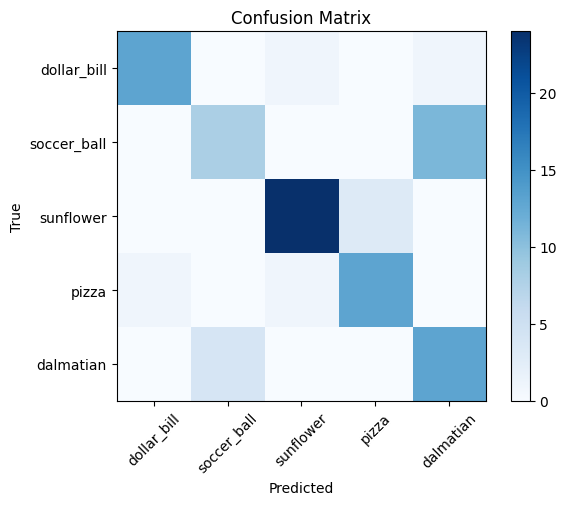

In [18]:
#Model Evaluation:
#Make predictions on the test set using the best model.
y_pred = rf_clf.predict(x_test)

#Evaluate the model using metrics such as accuracy, precision, recall, and F1-score.
print(classification_report(y_test, y_pred))

#Create a confusion matrix and classification report using confusion_matrix and classification_report from sklearn.metrics.
print(confusion_matrix(y_test, y_pred))

#Visualize the confusion matrix using matplotlib.pyplot.
cm = confusion_matrix(y_test, y_pred)
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Confusion Matrix')
plt.colorbar()
tick_marks = np.arange(len(image_dataset.target_names))
plt.xticks(tick_marks, image_dataset.target_names, rotation=45)
plt.yticks(tick_marks, image_dataset.target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()


##I see that my model performs fairly well overall with 76% accuracy, but the classes behave very differently. Class 0, 2, and 3 are recognized strongly, while class 1 and class 4 remain challenging, especially with class 1 being frequently misclassified as class 4. The confusion matrix confirms these patterns and helps me pinpoint exactly where my model still needs improvement.

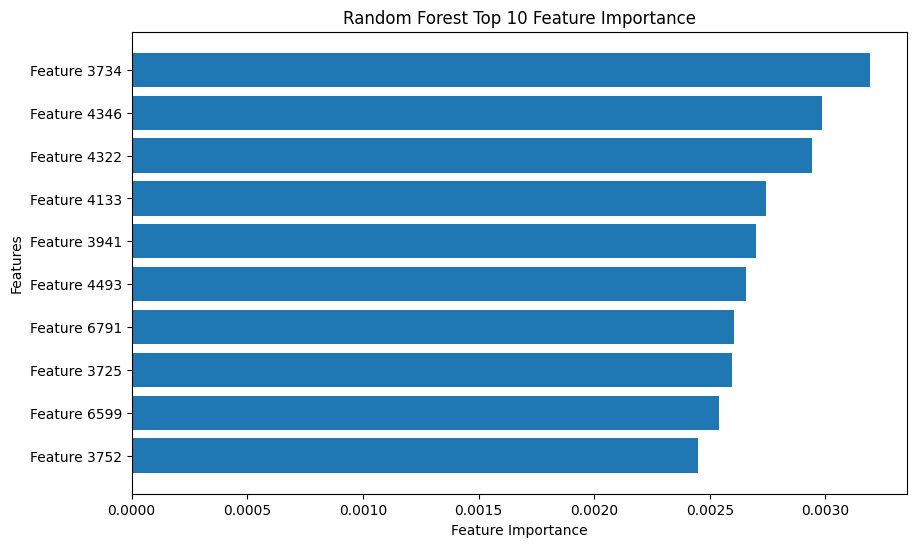

In [27]:
#Feature Importance Visualization:

#get indices of 10 top features
top_features_indices = rf_clf.feature_importances_.argsort()[-10:][::-1]

#sort them from important to less
sorted_importances = rf_clf.feature_importances_[top_features_indices]
# Generate labels for the top features, using their original indices
sorted_features_labels = [f"Feature {idx}" for idx in top_features_indices]

#bar plot
plt.figure(figsize=(10, 6))
# Plot only the top 10 features and their importances
plt.barh(sorted_features_labels, sorted_importances)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Random Forest Top 10 Feature Importance')
plt.gca().invert_yaxis() # Invert y-axis to have the most important feature at the top
plt.show()

#Get feature importances from the best model using the feature_importances_ attribute.
feature_importances = rf_clf.feature_importances_

In [23]:
def predict_image(image_path, model, image_dataset):
    img = imread('/content/New_image.png')
    img_resized = resize(img, (64, 64), anti_aliasing=True, mode='reflect')
    flat_data = img_resized.flatten()
    flat_data = np.array(flat_data)
    flat_data = flat_data.reshape(1, -1)
    prediction = model.predict(flat_data)
    return image_dataset.target_names[prediction[0]]

x_train, x_test, y_train, y_test = train_test_split(image_dataset.data, image_dataset.target, test_size=0.3, random_state=42)

predict_image('path/to/new_image.jpg', rf_clf, image_dataset)

'sunflower'

In [24]:
#Comparing with SVM:
#Implement SVM classification using SVC from sklearn.svm.
svm_clf = SVC()
svm_clf.fit(x_train, y_train)

#Follow a similar process as with Random Forest to train and evaluate the SVM model.
y_pred = svm_clf.predict(x_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.92      0.80      0.86        15
           1       0.79      0.58      0.67        19
           2       0.81      0.93      0.86        27
           3       0.80      0.53      0.64        15
           4       0.56      0.82      0.67        17

    accuracy                           0.75        93
   macro avg       0.78      0.73      0.74        93
weighted avg       0.77      0.75      0.75        93

[[12  0  0  0  3]
 [ 0 11  1  0  7]
 [ 0  0 25  2  0]
 [ 1  0  5  8  1]
 [ 0  3  0  0 14]]


##I see that my model achieves 75% accuracy, showing moderate performance with clear variation across classes. Classes 0 and 2 perform strongly, while classes 1 and 4 remain challenging. The confusion matrix highlights frequent misclassifications between classes 1 and 4, guiding me to focus on improving feature separation and data balance.

#Compare the results of Random Forest and SVM models.

##When I compare both models, I see that Random Forest performs better overall than SVM. The Random Forest model reaches 76% accuracy, while the SVM reaches 75%, showing that the ensemble approach generalizes more effectively on this dataset.

##Looking at class level performance, Random Forest shows higher precision, recall, and F1 scores for most classes, especially classes 0, 2, and 3, which the SVM struggles with. The SVM performs well in classes 0 and 2, but it has noticeably lower recall for classes 1 and 3, meaning it misses many true samples in those categories. The confusion matrices confirm this: SVM misclassifies class 1 and class 4 frequently, while Random Forest shows more stable predictions across all classes.

##Overall, Random Forest gives  more balanced performance, fewer misclassifications, and stronger reliability across categories, making it the better model for this dataset.

